# Sprint 14: Series Temporales y Pronóstico de Series Temporales

En este notebook exploraremos distintos ejercicios sobre series temporales y su pronóstico. Cada ejercicio incluye un párrafo introductorio, el objetivo, una explicación teórica y la solución en código. Se utilizará un archivo CSV sintético de consumo energético que se genera al inicio y se usará en todos los ejercicios.

In [1]:
import numpy as np
import pandas as pd
import os

# Crear directorio para almacenar el dataset si no existe
if not os.path.exists('datasets'):
    os.makedirs('datasets')

# Generar rango de fechas con frecuencia horaria: 2018-01-01 a 2018-06-30
rng = pd.date_range(start='2018-01-01', end='2018-06-30 23:00', freq='H')

# Simular consumo energético: base + ciclo diario + ruido aleatorio
consumption = 1000 + 200 * np.sin(2 * np.pi * rng.hour / 24) + 50 * np.random.randn(len(rng))
df = pd.DataFrame({'PJME_MW': consumption}, index=rng)
df.index.name = 'timestamp'

# Guardar el CSV sintético
df.to_csv('datasets/energy_consumption.csv')
print('CSV sintético generado en: datasets/energy_consumption.csv')

CSV sintético generado en: datasets/energy_consumption.csv


C:\Users\ljpca\AppData\Local\Temp\ipykernel_26604\4140428170.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rng = pd.date_range(start='2018-01-01', end='2018-06-30 23:00', freq='H')


In [2]:
df.head()

,PJME_MW
timestamp,
2018-01-01 00:00:00,934.670982
2018-01-01 01:00:00,1048.976151
2018-01-01 02:00:00,1072.654717
2018-01-01 03:00:00,1162.328901
2018-01-01 04:00:00,1210.845223


## Series Temporales

En esta sección se analizan ejercicios enfocados en el manejo y visualización de series temporales utilizando datos de consumo energético.

### Ejercicio 1: Trazado de gráficos de series temporales

En este ejercicio se cargará el dataset y se visualizará el consumo energético a lo largo del tiempo mediante un gráfico. 

**Objetivo:** Aprender a graficar series temporales utilizando Pandas.

**Explicación:** Se carga el CSV sintético, se filtra el periodo de enero a junio de 2018, se ordenan los datos por fecha y se grafica la serie para visualizar el comportamiento del consumo.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos y filtrar el periodo 2018-01 a 2018-06
data = pd.read_csv('datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data['2018-01':'2018-06']

In [5]:
data.head()

,PJME_MW
timestamp,
2018-01-01 00:00:00,934.670982
2018-01-01 01:00:00,1048.976151
2018-01-01 02:00:00,1072.654717
2018-01-01 03:00:00,1162.328901
2018-01-01 04:00:00,1210.845223


In [7]:
df_copy = data.copy().reset_index()
df_copy.head()

,timestamp,PJME_MW
0,2018-01-01 00:00:00,934.670982
1,2018-01-01 01:00:00,1048.976151
2,2018-01-01 02:00:00,1072.654717
3,2018-01-01 03:00:00,1162.328901
4,2018-01-01 04:00:00,1210.845223


In [8]:
df_copy.describe()

,timestamp,PJME_MW
count,4344,4344.000000
mean,2018-04-01 11:30:00,1001.503666
min,2018-01-01 00:00:00,659.356210
25%,2018-02-15 05:45:00,867.530009
50%,2018-04-01 11:30:00,1001.483504
75%,2018-05-16 17:15:00,1135.069654
max,2018-06-30 23:00:00,1378.429189
std,NaN,150.249943


In [15]:
df_copy.head(30)

,timestamp,PJME_MW
0,2018-01-01 00:00:00,934.670982
1,2018-01-01 01:00:00,1048.976151
2,2018-01-01 02:00:00,1072.654717
3,2018-01-01 03:00:00,1162.328901
4,2018-01-01 04:00:00,1210.845223
5,2018-01-01 05:00:00,1225.022515
6,2018-01-01 06:00:00,1193.145264
7,2018-01-01 07:00:00,1134.523180
8,2018-01-01 08:00:00,1162.525586
9,2018-01-01 09:00:00,1207.346327


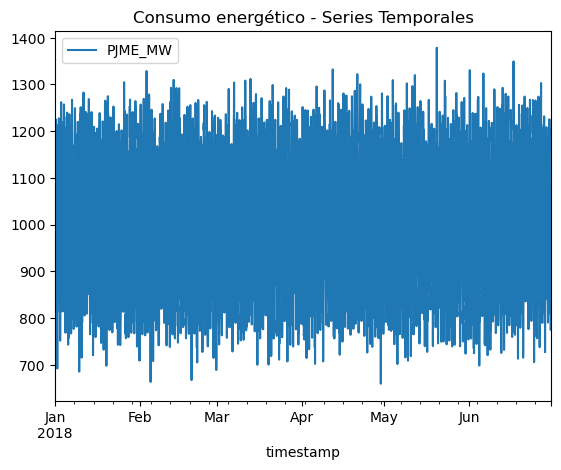

In [9]:
# Graficar la serie temporal
data.plot()
plt.title('Consumo energético - Series Temporales')
plt.show()

### Ejercicio 2: Cambio de intervalo mediante remuestreo

En este ejercicio se transformará la serie temporal agrupando los datos por día para observar tendencias a nivel diario. 

**Objetivo:** Modificar el intervalo de la serie temporal utilizando remuestreo.

**Explicación:** Se agrupan los datos a nivel diario mediante la función `resample` y se calcula la suma diaria para observar el comportamiento agregado del consumo energético.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar y filtrar datos, luego remuestrear a intervalos diarios
data = pd.read_csv('datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])

In [19]:
data.head()

,PJME_MW
timestamp,
2018-01-01 00:00:00,934.670982
2018-01-01 01:00:00,1048.976151
2018-01-01 02:00:00,1072.654717
2018-01-01 03:00:00,1162.328901
2018-01-01 04:00:00,1210.845223


In [20]:
data.sort_index(inplace=True)
data = data['2018-01':'2018-06'].resample('1D').sum()

<Figure size 1600x400 with 0 Axes>

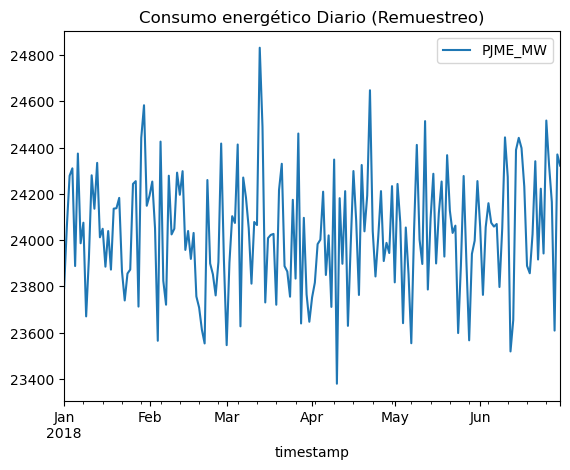

In [24]:
# Graficar la serie remuestreada
plt.figure(figsize=(16,4))
data.plot()
plt.title('Consumo energético Diario (Remuestreo)')
plt.show()

### Ejercicio 3: Suavizado con media móvil

En este ejercicio se aplicará un suavizado mediante una media móvil para reducir el ruido en la serie y resaltar la tendencia subyacente. 

**Objetivo:** Reducir las fluctuaciones en la serie temporal mediante una media móvil.

**Explicación:** Se aplica una media móvil de 10 días a la serie remuestreada para suavizar la variabilidad y facilitar la identificación de tendencias generales.

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar, filtrar y remuestrear datos
data = pd.read_csv('datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data['2018-01':'2018-06'].resample('1D').sum()

In [42]:
# Calcular la media móvil de 10 días
data['rolling_mean'] = data.rolling(10).mean()

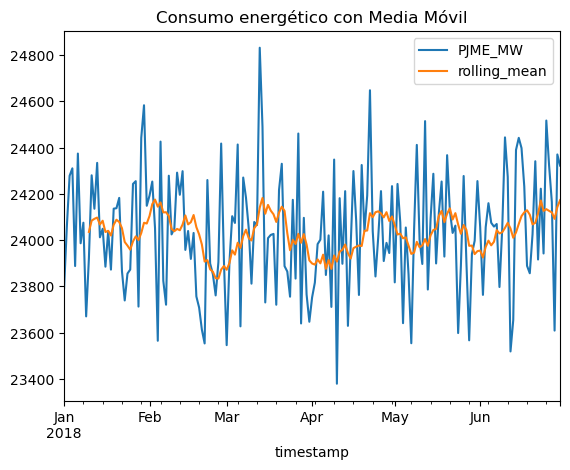

In [43]:
# Graficar la serie con media móvil
data.plot()
plt.title('Consumo energético con Media Móvil')
plt.show()

### Ejercicio 4: Análisis de tendencias y estacionalidad

En este ejercicio se descompondrá la serie temporal en sus componentes fundamentales para identificar patrones de tendencia y estacionalidad. 

**Objetivo:** Descomponer la serie temporal para identificar sus componentes: tendencia, estacionalidad y residuales.

**Explicación:** Se utiliza la función `seasonal_decompose` para separar la serie en componentes y se grafica la componente estacional para analizar patrones repetitivos en el tiempo.

In [44]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Cargar, filtrar y remuestrear datos
data = pd.read_csv('datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data['2018-01':'2018-06'].resample('1D').sum()

In [45]:
# Descomponer la serie temporal
decomposed = seasonal_decompose(data)

In [50]:
decomposed.seasonal

timestamp
2018-01-01    32.578017
2018-01-02   -21.000439
2018-01-03   -21.977572
2018-01-04    50.701550
2018-01-05   -35.594815
                ...    
2018-06-26   -21.000439
2018-06-27   -21.977572
2018-06-28    50.701550
2018-06-29   -35.594815
2018-06-30    21.883210
Freq: D, Name: seasonal, Length: 181, dtype: float64

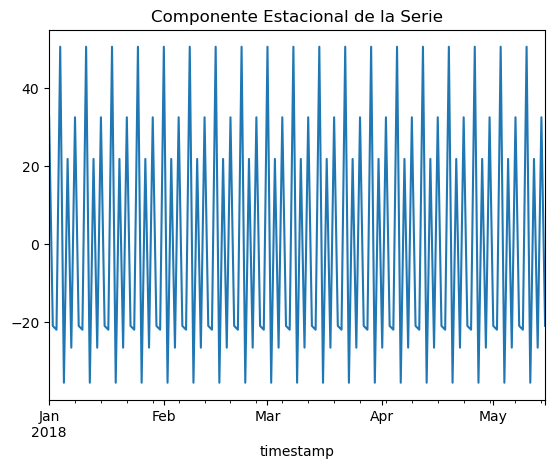

In [48]:
# Graficar la componente estacional para los primeros 15 días de enero
decomposed.seasonal['2018-01-01':'2018-05-15'].plot()
plt.title('Componente Estacional de la Serie')
plt.show()

### Ejercicio 5: Diferenciación para estacionariedad

En este ejercicio se calcularán las diferencias en la serie temporal para eliminar tendencias y lograr estacionariedad, complementado con estadísticas móviles para analizar su comportamiento. 

**Objetivo:** Aplicar la diferenciación a la serie para eliminar tendencias y lograr estacionariedad.

**Explicación:** Se calcula la diferencia entre valores consecutivos y se añaden columnas con la media y desviación móvil para analizar la variabilidad de la serie transformada.

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar, filtrar y remuestrear datos
data = pd.read_csv('datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data['2018-01':'2018-06'].resample('1D').sum()

In [52]:
data.head()

,PJME_MW
timestamp,
2018-01-01,23792.776608
2018-01-02,24059.568407
2018-01-03,24278.787659
2018-01-04,24310.950738
2018-01-05,23888.324216


In [53]:
# Diferenciar la serie
data -= data.shift()

data.head()

,PJME_MW
timestamp,
2018-01-01,NaN
2018-01-02,266.791798
2018-01-03,219.219252
2018-01-04,32.163079
2018-01-05,-422.626521


In [54]:
# Calcular la media y desviación móvil para 'PJME_MW'
data['mean'] = data['PJME_MW'].rolling(15).mean()
data['std'] = data['PJME_MW'].rolling(15).std()

In [56]:
data.head(16)

,PJME_MW,mean,std
timestamp,,,
2018-01-01,NaN,NaN,NaN
2018-01-02,266.791798,NaN,NaN
2018-01-03,219.219252,NaN,NaN
2018-01-04,32.163079,NaN,NaN
2018-01-05,-422.626521,NaN,NaN
2018-01-06,486.477211,NaN,NaN
2018-01-07,-387.970848,NaN,NaN
2018-01-08,88.983564,NaN,NaN
2018-01-09,-405.230835,NaN,NaN


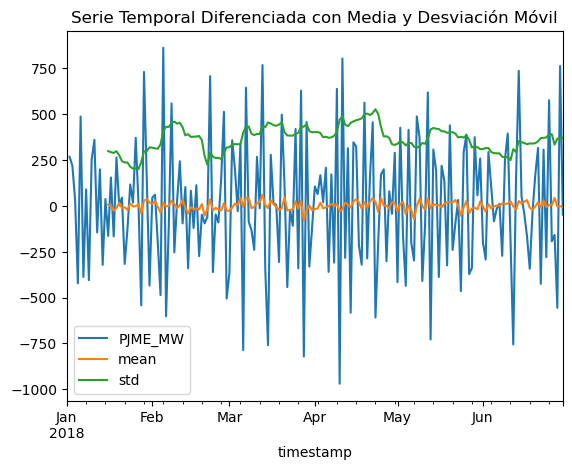

In [57]:
# Graficar la serie diferenciada
data.plot()
plt.title('Serie Temporal Diferenciada con Media y Desviación Móvil')
plt.show()

## Momento 2: Pronóstico de Series Temporales

En esta sección se presentan ejercicios relacionados con la preparación y el pronóstico de series temporales, abarcando desde la división de datos hasta el entrenamiento de un modelo de regresión lineal.

### Ejercicio 1: División de datos (Split)

En este ejercicio se realizará la división de la serie en conjuntos de entrenamiento y prueba respetando el orden temporal, para asegurar que la secuencia de datos se mantenga. 

**Objetivo:** Separar los datos en conjuntos de entrenamiento y prueba sin alterar la secuencia temporal.

**Explicación:** Se utiliza `train_test_split` con `shuffle=False` para garantizar que la división respete el orden cronológico de los datos.

In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Cargar y remuestrear datos a intervalos diarios
data = pd.read_csv('datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data.resample('1D').sum()

# Dividir datos en entrenamiento y prueba (80%-20%) sin mezclar el orden
train, test = train_test_split(data, shuffle=False, test_size=0.2)

print('Periodo de entrenamiento:', train.index.min(), 'a', train.index.max())
print('Periodo de prueba:', test.index.min(), 'a', test.index.max())

Periodo de entrenamiento: 2018-01-01 00:00:00 a 2018-05-24 00:00:00
Periodo de prueba: 2018-05-25 00:00:00 a 2018-06-30 00:00:00


### Ejercicio 2: Modelo con horizonte de pronóstico de 1 día

En este ejercicio se construirá un modelo de pronóstico simple que utiliza el valor del día anterior para predecir el consumo actual, evaluando su desempeño mediante el MAE. 

**Objetivo:** Evaluar un modelo de pronóstico simple que utiliza el valor del día anterior para predecir el consumo actual.

**Explicación:** Se calcula la mediana del consumo y se utiliza la técnica de predicción por desplazamiento (lag) para estimar el consumo del día siguiente. Se evalúa el desempeño con el Error Absoluto Medio (MAE).

In [59]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Cargar y remuestrear datos a nivel diario
data = pd.read_csv('datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data.resample('1D').sum()

# Dividir datos en entrenamiento y prueba
train, test = train_test_split(data, shuffle=False, test_size=0.2)

print('Consumo medio diario (mediana):', test['PJME_MW'].median())

# Predicción simple: se utiliza el valor del día anterior
pred_previous = test.shift()
pred_previous.iloc[0] = train.iloc[-1]
print('Error Absoluto Medio (EAM):', mean_absolute_error(test, pred_previous))

Consumo medio diario (mediana): 24059.030088067968
Error Absoluto Medio (EAM): 276.2906657217476


### Ejercicio 3: Creación de características para pronóstico

En este ejercicio se crearán variables adicionales a partir de la serie temporal para capturar patrones y mejorar la precisión del pronóstico. 

**Objetivo:** Generar variables (features) que ayuden a mejorar la precisión del pronóstico.

**Explicación:** Se crean variables a partir de la serie temporal, como componentes temporales (año, mes, día, día de la semana), lags y una media móvil, que permiten capturar patrones y tendencias en el consumo.

In [61]:
import pandas as pd
import numpy as np

# Cargar y remuestrear datos a nivel diario
data = pd.read_csv('datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data.resample('1D').sum()

def make_features(data, max_lag, rolling_mean_size):
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['PJME_MW'].shift(lag)
    
    data['rolling_mean'] = data['PJME_MW'].shift().rolling(rolling_mean_size).mean()

make_features(data, 4, 4)
data.head(10)

,PJME_MW,year,month,day,dayofweek,lag_1,lag_2,lag_3,lag_4,rolling_mean
timestamp,,,,,,,,,,
2018-01-01,23792.776608,2018,1,1,0,NaN,NaN,NaN,NaN,NaN
2018-01-02,24059.568407,2018,1,2,1,23792.776608,NaN,NaN,NaN,NaN
2018-01-03,24278.787659,2018,1,3,2,24059.568407,23792.776608,NaN,NaN,NaN
2018-01-04,24310.950738,2018,1,4,3,24278.787659,24059.568407,23792.776608,NaN,NaN
2018-01-05,23888.324216,2018,1,5,4,24310.950738,24278.787659,24059.568407,23792.776608,24110.520853
2018-01-06,24374.801427,2018,1,6,5,23888.324216,24310.950738,24278.787659,24059.568407,24134.407755
2018-01-07,23986.830579,2018,1,7,6,24374.801427,23888.324216,24310.950738,24278.787659,24213.216010
2018-01-08,24075.814143,2018,1,8,0,23986.830579,24374.801427,23888.324216,24310.950738,24140.226740
2018-01-09,23670.583308,2018,1,9,1,24075.814143,23986.830579,24374.801427,23888.324216,24081.442591


### Ejercicio 4: Entrenamiento de un modelo de regresión lineal

En este ejercicio se entrenará un modelo de regresión lineal utilizando las características generadas para predecir el consumo energético, y se evaluará su desempeño mediante el MAE. 

**Objetivo:** Entrenar un modelo de regresión lineal utilizando las nuevas características para predecir el consumo energético.

**Explicación:** Se generan las variables explicativas, se dividen los datos en entrenamiento y prueba, y se entrena un modelo de regresión lineal. Finalmente, se evalúa el desempeño del modelo mediante el Error Absoluto Medio (MAE).

In [62]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Cargar y remuestrear datos a nivel diario
data = pd.read_csv('datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data.resample('1D').sum()

def make_features(data, max_lag, rolling_mean_size):
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['PJME_MW'].shift(lag)
    
    data['rolling_mean'] = data['PJME_MW'].shift().rolling(rolling_mean_size).mean()

make_features(data, 6, 10)

# Dividir los datos en conjuntos de entrenamiento y prueba
train, test = train_test_split(data, shuffle=False, test_size=0.2)
train = train.dropna()

features_train = train.drop(['PJME_MW'], axis=1)
target_train = train['PJME_MW']

features_test = test.drop(['PJME_MW'], axis=1)
target_test = test['PJME_MW']

model = LinearRegression()
model.fit(features_train, target_train)

pred_train = model.predict(features_train)
pred_test = model.predict(features_test)

print('EAM para entrenamiento:', mean_absolute_error(target_train, pred_train))
print('EAM para prueba:', mean_absolute_error(target_test, pred_test))

EAM para entrenamiento: 203.60265884220794
EAM para prueba: 231.90759599800919


In [63]:
data.head()

,PJME_MW,year,month,day,dayofweek,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,rolling_mean
timestamp,,,,,,,,,,,,
2018-01-01,23792.776608,2018,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-02,24059.568407,2018,1,2,1,23792.776608,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,24278.787659,2018,1,3,2,24059.568407,23792.776608,NaN,NaN,NaN,NaN,NaN
2018-01-04,24310.950738,2018,1,4,3,24278.787659,24059.568407,23792.776608,NaN,NaN,NaN,NaN
2018-01-05,23888.324216,2018,1,5,4,24310.950738,24278.787659,24059.568407,23792.776608,NaN,NaN,NaN


In [69]:
data.columns

Index(['PJME_MW', 'year', 'month', 'day', 'dayofweek', 'lag_1', 'lag_2',
       'lag_3', 'lag_4', 'lag_5', 'lag_6', 'rolling_mean'],
      dtype='object')

In [71]:
# Dividir los datos en conjuntos de entrenamiento y prueba
data = data.dropna()

X = data[['year', 'month', 'day', 'dayofweek', 'rolling_mean']]
y = data['PJME_MW']

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('EAM para prueba:', mean_absolute_error(y_test, y_pred))

KeyError: ('year', 'month', 'day', 'dayofweek', 'rolling_mean')